In [11]:
import h5py
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# Paths to your files (edit for your sample)
# ------------------------------------------------------------
# h5_path = "/home/puneet/mk/data/hist2st_dataset/23209_C1.h5"
# h5ad_path = "/home/puneet/mk/data/hist2st_dataset/23209_C1.h5ad"

# h5_path = "/home/puneet/mk/data/her2st_dataset_RGB/224/A1.h5"
# h5ad_path = "/home/puneet/mk/data/her2st_dataset_RGB/224/A1.h5ad"

h5_path = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_patches.h5"
h5ad_path = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression.h5ad"

Cell 2: Explore .h5 file (patches + coords)

In [12]:
# Open H5 file
with h5py.File(h5_path, "r") as f:
    print(" Keys in H5 file:")
    for k in f.keys():
        print(f"  {k} → shape: {f[k].shape}")

    # Load datasets
    patches = f["patches"][:]
    pixel_x = f["pixel_x"][:]
    pixel_y = f["pixel_y"][:]
    x = f["x"][:]
    y = f["y"][:]

print("\n Loaded H5 data:")
print(f"Patches shape: {patches.shape} (N, H, W, C)")
print(f"pixel_x range: {pixel_x.min():.1f} → {pixel_x.max():.1f}")
print(f"pixel_y range: {pixel_y.min():.1f} → {pixel_y.max():.1f}")


 Keys in H5 file:
  cell_ids → shape: (167780,)
  centroid_um → shape: (167780, 2)
  coords_px → shape: (167780, 2)
  masks → shape: (167780, 128, 128)
  patches → shape: (167780, 128, 128, 3)
  pixel_x → shape: (167780,)
  pixel_y → shape: (167780,)
  polygon_num_vertices → shape: (167780,)
  polygon_vertices_um → shape: (167780, 13, 2)


KeyError: "Unable to synchronously open object (object 'x' doesn't exist)"

In [13]:
import h5py
import numpy as np

with h5py.File(h5_path, "r") as f:
    centroid_um = f["centroid_um"][:]   # (N, 2)

x = centroid_um[:, 0]
y = centroid_um[:, 1]

print(f"x (centroid_um) range: {x.min():.2f} → {x.max():.2f}")
print(f"y (centroid_um) range: {y.min():.2f} → {y.max():.2f}")

x (centroid_um) range: 2.13 → 7523.09
y (centroid_um) range: 1.37 → 5476.27


In [10]:
import h5py
import numpy as np

# Open H5 file
with h5py.File(h5_path, "r") as f:
    print("Keys in H5 file:")
    for k in f.keys():
        item = f[k]
        if hasattr(item, 'shape'):  # Dataset only
            print(f"  📊 {k} → shape: {item.shape}")
        else:  # Group
            print(f"  📁 {k} → Group (subkeys: {list(item.keys())})")
    
    # Load datasets
    patches = f["patches"][:]
    pixel_x = f["pixel_x"][:]
    pixel_y = f["pixel_y"][:]
    x = f["x"][:]      # Grid X coords (normalized)
    y = f["y"][:]      # Grid Y coords (normalized)

print("\n✅ Loaded H5 data:")
print(f"Patches shape: {patches.shape} (N, H, W, C)")
print(f"pixel_x range: {pixel_x.min():.1f} → {pixel_x.max():.1f} (WSI pixels)")
print(f"pixel_y range: {pixel_y.min():.1f} → {pixel_y.max():.1f} (WSI pixels)")
print(f"x range: {x.min():.3f} → {x.max():.3f} (GRID coords)")
print(f"y range: {y.min():.3f} → {y.max():.3f} (GRID coords)")

# Print FIRST 5 values
print("\n📍 Sample coordinates (first 5 spots):")
for i in range(5):
    print(f"Spot {i}: pixel({pixel_x[i]:.0f},{pixel_y[i]:.0f}) → grid({x[i]:.3f},{y[i]:.3f})")


Keys in H5 file:
  📊 patches → shape: (346, 224, 224, 3)
  📊 pixel_x → shape: (346,)
  📊 pixel_y → shape: (346,)
  📊 x → shape: (346,)
  📊 y → shape: (346,)

✅ Loaded H5 data:
Patches shape: (346, 224, 224, 3) (N, H, W, C)
pixel_x range: 407.0 → 5454.0 (WSI pixels)
pixel_y range: 2394.0 → 5911.0 (WSI pixels)
x range: 3.000 → 26.000 (GRID coords)
y range: 12.000 → 28.000 (GRID coords)

📍 Sample coordinates (first 5 spots):
Spot 0: pixel(1923,2622) → grid(10.000,13.000)
Spot 1: pixel(1926,2844) → grid(10.000,14.000)
Spot 2: pixel(1928,3059) → grid(10.000,15.000)
Spot 3: pixel(1927,3279) → grid(10.000,16.000)
Spot 4: pixel(1921,3498) → grid(10.000,17.000)


Cell 3: Show 5 random image patches

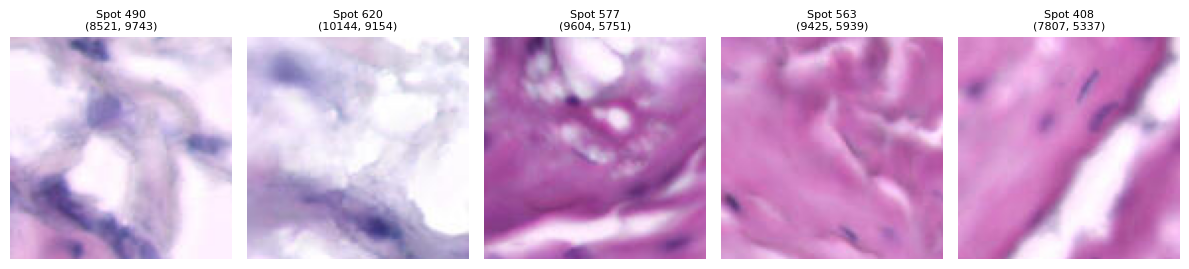

In [6]:
# Display 5 random patches from H5
plt.figure(figsize=(12, 6))
indices = random.sample(range(len(patches)), 5)

for i, idx in enumerate(indices, 1):
    plt.subplot(1, 5, i)
    plt.imshow(patches[idx])
    plt.title(f"Spot {idx}\n({int(pixel_x[idx])}, {int(pixel_y[idx])})", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


Loaded:
 patches: (294, 224, 224, 3)
 pixel_x range: 270 → 6692
 pixel_y range: 1160 → 7546
Reconstructed image shape: (6610, 6646, 3)


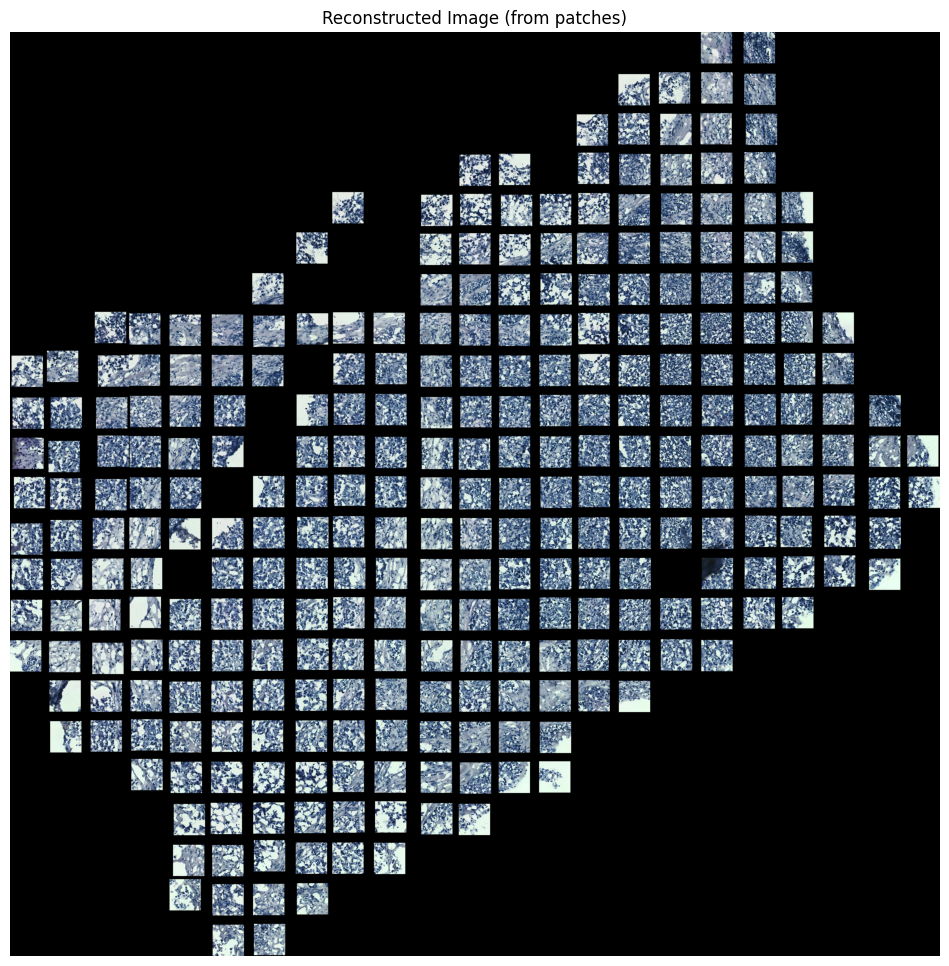

Saved to: A1_reconstructed.png


In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_from_patches_centered(
    h5_path,
    patch_key="patches",
    px_key="pixel_x",
    py_key="pixel_y",
    show=True,
    save_path=None
):
    """
    Reconstruct full image from patches where pixel_x/y are PATCH CENTERS.
    """

    # ----------------------------
    # Load data
    # ----------------------------
    with h5py.File(h5_path, "r") as f:
        patches = f[patch_key][:]        # (N, H, W, 3) RGB
        px = f[px_key][:].astype(int)    # centers
        py = f[py_key][:].astype(int)

    N, H, W, C = patches.shape
    half = H // 2

    print("Loaded:")
    print(" patches:", patches.shape)
    print(" pixel_x range:", px.min(), "→", px.max())
    print(" pixel_y range:", py.min(), "→", py.max())

    # ----------------------------
    # Canvas size
    # ----------------------------
    min_x = px.min() - half
    min_y = py.min() - half
    max_x = px.max() + half
    max_y = py.max() + half

    canvas_w = max_x - min_x
    canvas_h = max_y - min_y

    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.float32)
    count  = np.zeros((canvas_h, canvas_w, 1), dtype=np.float32)

    # ----------------------------
    # Paste patches
    # ----------------------------
    for patch, cx, cy in zip(patches, px, py):
        x0 = cx - half - min_x
        y0 = cy - half - min_y
        x1 = x0 + W
        y1 = y0 + H

        canvas[y0:y1, x0:x1] += patch
        count[y0:y1, x0:x1] += 1

    # ----------------------------
    # Average overlaps
    # ----------------------------
    canvas /= np.maximum(count, 1)
    canvas = np.clip(canvas, 0, 255).astype(np.uint8)

    print("Reconstructed image shape:", canvas.shape)

    # ----------------------------
    # Display
    # ----------------------------
    if show:
        plt.figure(figsize=(12, 12))
        plt.imshow(canvas)
        plt.axis("off")
        plt.title("Reconstructed Image (from patches)")
        plt.show()

    # ----------------------------
    # Save
    # ----------------------------
    if save_path:
        plt.imsave(save_path, canvas)
        print("Saved to:", save_path)

    return canvas


# ===============================
# USAGE
# ===============================
if __name__ == "__main__":
    h5_file = "/home/puneet/suresh/mk/data/hist2st_dataset/23209_C1.h5"

    reconstruct_from_patches_centered(
        h5_path=h5_file,
        save_path="A1_reconstructed.png"
    )

Cell 4: Explore .h5ad file (expression + metadata)

In [33]:
adata = sc.read_h5ad(h5ad_path)

print(" AnnData summary:")
print(adata)
print("\n.obs (spot metadata):")
print(adata.obs.head())

print("\n.var (gene names):")
print(adata.var_names[:10])

# Basic structure
print(f"\nExpression matrix shape: {adata.X.shape} (spots × genes)")


 AnnData summary:
AnnData object with n_obs × n_vars = 346 × 15045
    obs: 'spot_id', 'x', 'y', 'pixel_x', 'pixel_y'

.obs (spot metadata):
  spot_id   x   y  pixel_x  pixel_y
0   10x13  10  13     1923     2622
1   10x14  10  14     1926     2844
2   10x15  10  15     1928     3059
3   10x16  10  16     1927     3279
4   10x17  10  17     1921     3498

.var (gene names):
Index(['FO538757.1', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4',
       'ISG15', 'AGRN', 'RNF223'],
      dtype='object')

Expression matrix shape: (346, 15045) (spots × genes)


In [15]:
assert len(adata.obs) == patches.shape[0], "Mismatch between H5 and H5AD!"
print("Number of spots match between H5 and H5AD!")

# Check coordinate alignment
diff_x = np.abs(adata.obs["pixel_x"].values - pixel_x)
diff_y = np.abs(adata.obs["pixel_y"].values - pixel_y)

print(f"Max deviation in pixel_x: {diff_x.max():.4f}")
print(f"Max deviation in pixel_y: {diff_y.max():.4f}")


Number of spots match between H5 and H5AD!
Max deviation in pixel_x: 0.0000
Max deviation in pixel_y: 0.0000


Xenium_data_visualization

🧩 Exploring H5 file: /home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_patches.h5

🔹 Keys in H5 file:
  cell_ids → shape: (167780,), dtype: uint32
  centroid_um → shape: (167780, 2), dtype: float32
  coords_px → shape: (167780, 2), dtype: float64
  masks → shape: (167780, 128, 128), dtype: uint8
  patches → shape: (167780, 128, 128, 3), dtype: uint8
  pixel_x → shape: (167780,), dtype: float64
  pixel_y → shape: (167780,), dtype: float64
  polygon_num_vertices → shape: (167780,), dtype: int32
  polygon_vertices_um → shape: (167780, 13, 2), dtype: float32

✅ Loaded patches: (167780, 128, 128, 3)
pixel_x range: 5981.9 → 26705.4
pixel_y range: 6720.0 → 21837.9

🧠 Exploring H5AD file: /home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression.h5ad

📊 AnnData summary:
AnnData object with n_obs × n_vars = 167780 × 541
    obs: 'x_pixel', 'y_pixel', 'x_um', 'y_um', 'cell_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial_metadata

/tmp/ipykernel_2641443/639927158.py:66: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/puneet/anaconda3/envs/isbi/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


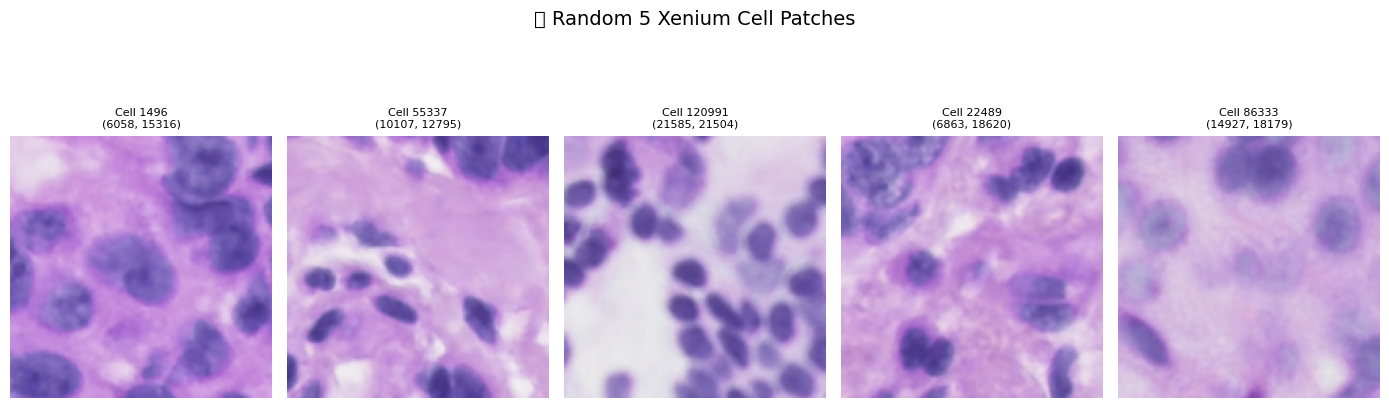

In [1]:
import h5py
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# ------------------------------------------------------------
# 1️⃣ Define file paths
# ------------------------------------------------------------
output_dir = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output"
h5_path = os.path.join(output_dir, "cells_patches.h5")
h5ad_path = os.path.join(output_dir, "cells_expression.h5ad")

# ------------------------------------------------------------
# 2️⃣ Explore H5 file
# ------------------------------------------------------------
print("🧩 Exploring H5 file:", h5_path)
with h5py.File(h5_path, "r") as f:
    print("\n🔹 Keys in H5 file:")
    for k in f.keys():
        obj = f[k]
        if isinstance(obj, h5py.Dataset):
            print(f"  {k} → shape: {obj.shape}, dtype: {obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"  {k} → group")

    patches = f["patches"][:]
    pixel_x = f["pixel_x"][:]
    pixel_y = f["pixel_y"][:]

print(f"\n✅ Loaded patches: {patches.shape}")
print(f"pixel_x range: {pixel_x.min():.1f} → {pixel_x.max():.1f}")
print(f"pixel_y range: {pixel_y.min():.1f} → {pixel_y.max():.1f}")

# ------------------------------------------------------------
# 3️⃣ Explore H5AD file
# ------------------------------------------------------------
print("\n🧠 Exploring H5AD file:", h5ad_path)
adata = sc.read_h5ad(h5ad_path)

print("\n📊 AnnData summary:")
print(adata)

print("\n.obs (spot metadata):")
print(adata.obs.head())

print("\n.var (first 10 gene names):")
print(list(adata.var_names[:10]))

print(f"\n🧮 Expression matrix shape: {adata.X.shape} (cells × genes)")

# ------------------------------------------------------------
# 4️⃣ Visualize 5 random patches
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))
indices = random.sample(range(len(patches)), 5)

for i, idx in enumerate(indices, 1):
    plt.subplot(1, 5, i)
    plt.imshow(patches[idx])
    plt.title(f"Cell {idx}\n({int(pixel_x[idx])}, {int(pixel_y[idx])})", fontsize=8)
    plt.axis("off")

plt.suptitle("🧩 Random 5 Xenium Cell Patches", fontsize=14)
plt.tight_layout()
plt.show()


In [2]:
import h5py
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# Paths to your files (edit for your sample)
# ------------------------------------------------------------
h5_path = "/home/puneet/mk/data/hist2st_dataset/23209_C1.h5"
h5ad_path = "/home/puneet/mk/data/hist2st_dataset/23209_C1.h5ad"

# ------------------------------------------------------------
# SAFE H5 EXPLORATION (fixes Group.shape error)
# ------------------------------------------------------------
print("🔍 Exploring H5 structure...")
with h5py.File(h5_path, 'r') as f:
    print("Top-level keys:")
    for k in f.keys():
        item = f[k]
        if isinstance(item, h5py.Dataset):
            print(f"  📊 {k} → shape: {item.shape}, dtype: {item.dtype}")
        else:
            print(f"  📁 {k} → Group (subkeys: {list(item.keys())})")
    
    # Common Hist2ST patterns - check these:
    common_paths = ['patches', 'patches/data', 'spots/expression', 'coords']
    for path in common_paths:
        if path in f:
            item = f[path]
            print(f"  ✅ Found '{path}': {type(item).__name__}, shape: {getattr(item, 'shape', 'N/A')}")

# ------------------------------------------------------------
# LOAD & VISUALIZE (pick your actual dataset names above)
# ------------------------------------------------------------
print("\n📈 Loading data...")

# Replace these with ACTUAL dataset paths from above output:
# Example patterns for Hist2ST datasets:
with h5py.File(h5_path, 'r') as f:
    # patches = f["patches"][:]  # or f["patches/data"][:]
    # coords = f["coords"][:]    # or f["spatial/coords"][:]
    # expr = f["expression"][:]  # gene expression matrix
    pass

print("✅ Run the exploration first, then update dataset paths!")
print("Then use scanpy: sc.read_h5ad(h5ad_path) for AnnData object")

🔍 Exploring H5 structure...
Top-level keys:
  📁 coords → Group (subkeys: ['Unnamed: 4', 'lab', 'tumor', 'xcoord', 'ycoord'])
  📊 patches → shape: (294, 224, 224, 3), dtype: uint8
  📊 pixel_x → shape: (294,), dtype: int64
  📊 pixel_y → shape: (294,), dtype: int64
  📊 spot_id → shape: (294,), dtype: |S5
  ✅ Found 'patches': Dataset, shape: (294, 224, 224, 3)
  ✅ Found 'coords': Group, shape: N/A

📈 Loading data...
✅ Run the exploration first, then update dataset paths!
Then use scanpy: sc.read_h5ad(h5ad_path) for AnnData object


In [4]:
with h5py.File(h5_path, 'r') as f:
    print("📍 Pixel coords (numeric):")
    print(f"  pixel_x range: {f['pixel_x'][:].min():.0f} → {f['pixel_x'][:].max():.0f}")
    print(f"  pixel_y range: {f['pixel_y'][:].min():.0f} → {f['pixel_y'][:].max():.0f}")
    
    print("\n🧬 ST coords (check dtypes):")
    for coord in ['xcoord', 'ycoord', 'tumor', 'lab']:
        data = f[f'coords/{coord}'][:]
        print(f"  {coord}: dtype={data.dtype}, shape={data.shape}")
        if data.dtype.kind in 'if':  # numeric
            print(f"    range: {data.min():.0f} → {data.max():.0f}")
        else:  # strings
            print(f"    unique: {np.unique(data)[:5]}...")  # first 5 unique values


📍 Pixel coords (numeric):
  pixel_x range: 270 → 6692
  pixel_y range: 1160 → 7546

🧬 ST coords (check dtypes):
  xcoord: dtype=|S16, shape=(294,)
    unique: [b'C1_1.931_19.983' b'C1_1.959_17.104' b'C1_1.95_18.986'
 b'C1_1.969_12.972' b'C1_1.974_17.976']...
  ycoord: dtype=|S6, shape=(294,)
    unique: [b'1.931' b'1.95' b'1.959' b'1.969' b'1.974']...
  tumor: dtype=|S4, shape=(294,)
    unique: [b'L1' b'L10' b'L100' b'L101' b'L102']...
  lab: dtype=|S6, shape=(294,)
    unique: [b'10.895' b'10.923' b'10.924' b'10.939' b'10.942']...
